# Problem Statement
* Title: Cardiovascular Disease Risk Prediction

* Description: Cardiovascular diseases (CVDs) are the leading cause of death globally. Early detection is crucial for effective treatment and management. The challenge is to identify the presence of cardiovascular disease in patients based on their medical examination results and lifestyle information.

* Objective: To build a Machine Learning model that can accurately predict the presence of cardiovascular disease (cardio = 1) or its absence (cardio = 0) in a patient using a dataset of 70,000 records containing objective, examination, and subjective features.

## 1) Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv('cardio_train.csv', sep=';')
print("Dataset loaded successfully.")



Dataset loaded successfully.


## 2) Initial Inspection ##



In [3]:

df


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [4]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
print("Rows and Cols :")
df.shape

Rows and Cols :


(70000, 13)

In [6]:
print("Data Types of All Columns : ")
df.dtypes

Data Types of All Columns : 


id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [7]:
print("Statistical Description:")
display(df.describe().T)

Statistical Description:


,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [8]:
print("max height : ",df["height"].max())
print("min height : ",df["height"].min())
print("\nmax height : ",df["weight"].max())
print("min height : ",df["weight"].min())
print("\nmax ap_hi : ",df["ap_hi"].max())
print("min ap_hi : ",df["ap_hi"].min())
print("\nmax ap_lo : ",df["ap_lo"].max())
print("min ap_lo : ",df["ap_lo"].min())

max height :  250
min height :  55

max height :  200.0
min height :  10.0

max ap_hi :  16020
min ap_hi :  -150

max ap_lo :  11000
min ap_lo :  -70


# 3) Visulization


### 1) Age Distribution 

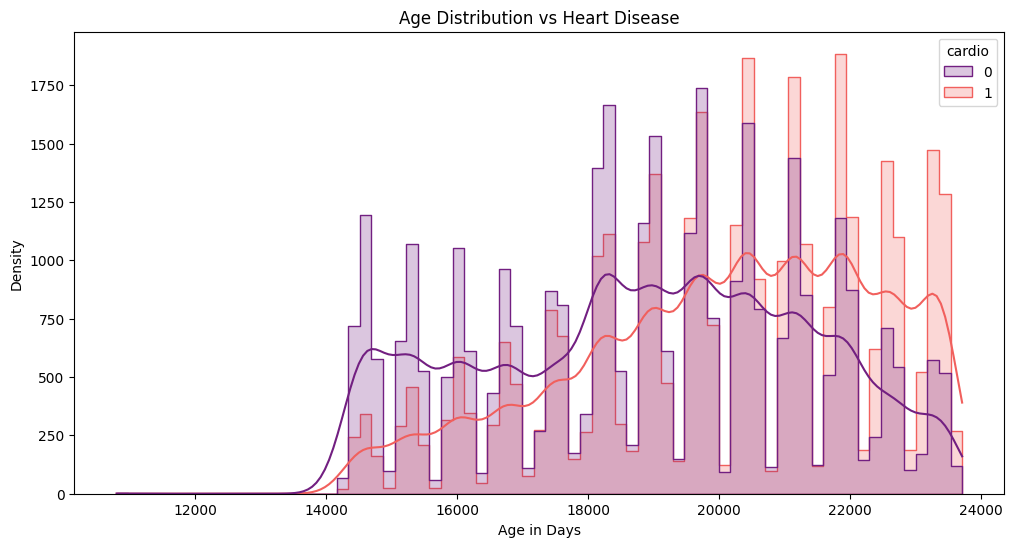

In [9]:
# Visualizing Age (recorded in days) relative to the target
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x='age', hue='cardio', kde=True, element="step", palette='magma')

plt.title('Age Distribution vs Heart Disease')
plt.xlabel('Age in Days')
plt.ylabel('Density')
plt.show()

### 2) Outlier Detection for Physical Metrics

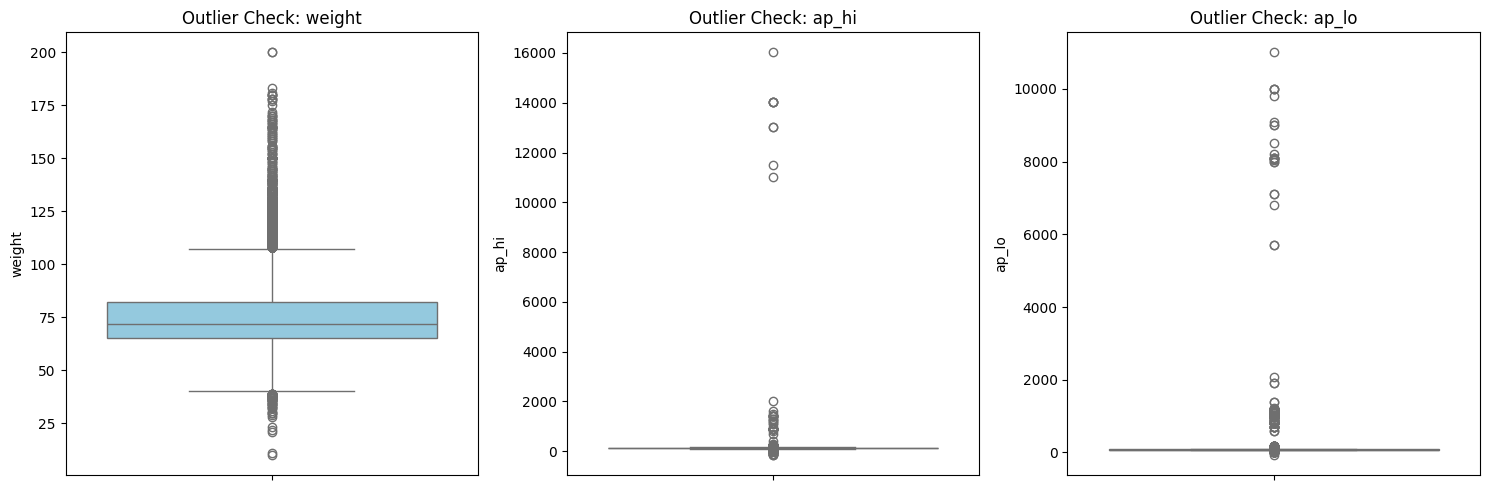

In [10]:
# Identifying range issues in Blood Pressure and Weight
metrics = ['weight', 'ap_hi', 'ap_lo']

plt.figure(figsize=(15, 5))
for i, col in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outlier Check: {col}')

plt.tight_layout()
plt.show()

### 3) Correlation Heatmap

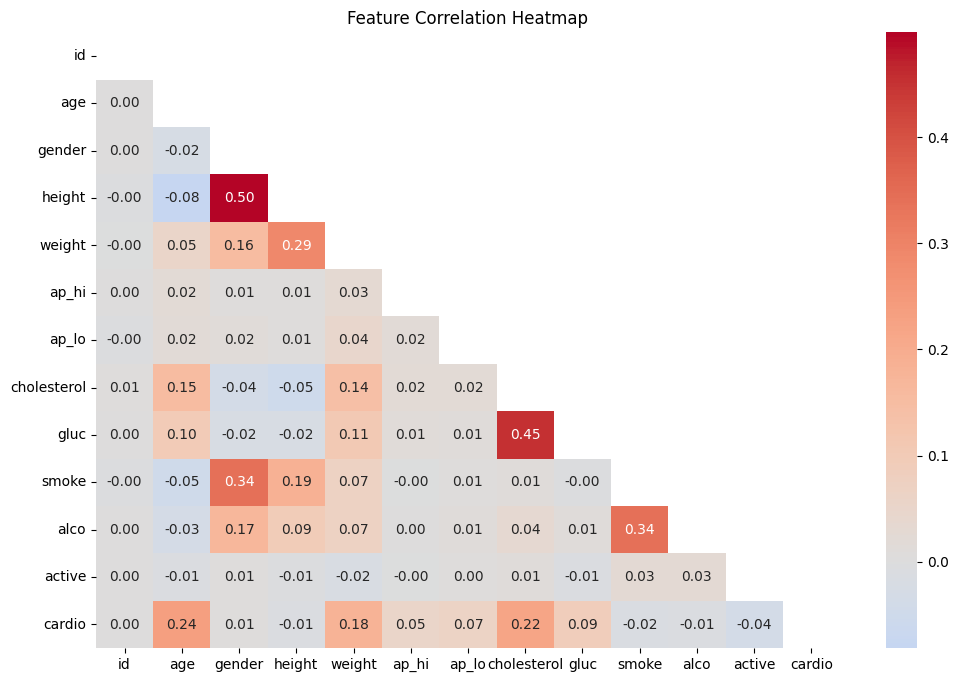

In [11]:
# Calculating and plotting correlations between all features
plt.figure(figsize=(12, 8))

mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)

plt.title('Feature Correlation Heatmap')
plt.show()

### 4) Categorical Distribution

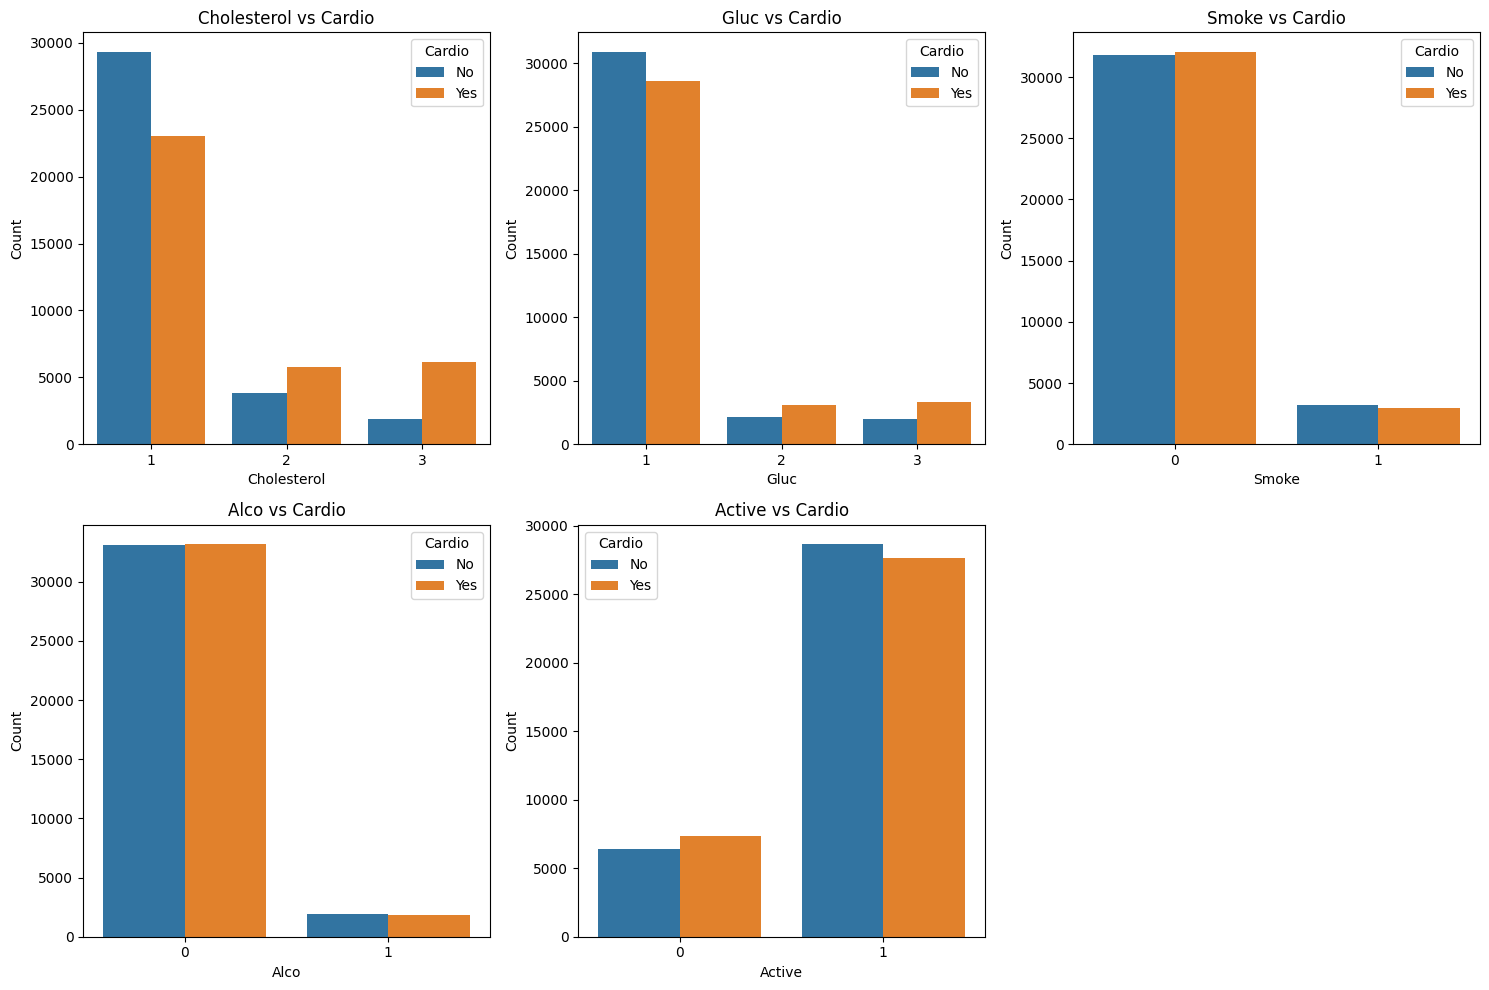

In [12]:
categorical_features = ["cholesterol", "gluc", "smoke", "alco", "active"]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(categorical_features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=feature, hue="cardio", data=df)
    plt.title(f"{feature.capitalize()} vs Cardio", fontsize=12)
    plt.xlabel(feature.capitalize())
    plt.ylabel("Count")
    plt.legend(title="Cardio", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

### **Data Exploration Summary & Insights**

| Feature | Min Value | Max Value | Mean | Observation / Required Action |
| :--- | :---: | :---: | :---: | :--- |
| **Age** | 10,798 | 23,713 | 19,468 | Values are in days (~29 to 64 years). Should be converted to years for better interpretability. |
| **Gender** | 1 | 2 | 1.35 | Binary Categorical: 1 = Female, 2 = Male. |
| **Height** | 55 cm | 250 cm | 164.3 cm | Extreme outliers present (55 cm is too low). Need to filter for realistic heights. |
| **Weight** | 10.0 kg | 200.0 kg | 74.2 kg | Minimum weight of 10 kg is an error. Suggest filtering to keep records above 30 kg. |
| **Systolic BP (ap_hi)** | -150 | 16,020 | 128.8 | High noise: Negative values and 16,000+ are physiologically impossible. Keep range ~80-250. |
| **Diastolic BP (ap_lo)** | -70 | 11,000 | 96.6 | High noise: Negative values and 11,000+ are errors. Keep range ~40-150. |
| **Cholesterol** | 1 | 3 | 1.36 | Categorical: 1: normal, 2: above normal, 3: well above normal. |
| **Cardio (Target)** | 0 | 1 | 0.50 | The dataset is perfectly balanced (approx. 50% each class). |